# Setup

In [105]:
import os
import warnings
from pathlib import Path
import math
import gc
import dask
import dask.dataframe as dd

# Data Manipulation 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# import modin.pandas as pd
from pandas.api.types import CategoricalDtype
from IPython.display import display

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
from pandas.plotting import scatter_matrix
from mpl_toolkits.mplot3d import Axes3D

# Feature Selection and Encoding
from sklearn.feature_selection import RFE, RFECV, mutual_info_regression
from sklearn.svm import SVR

#Feature imputation
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize
from category_encoders import MEstimateEncoder

# Dimensionality Reduction / Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

#Model selection
from sklearn.model_selection import KFold, cross_val_score, train_test_split

# Machine learning 
from xgboost import XGBRegressor
import sklearn.ensemble as ske
from sklearn import datasets, model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
# import tensorflow as tf

# Grid and Random Search
import scipy.stats as st
from scipy.stats import randint as sp_randint
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc

# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Plot the Figures Inline
%matplotlib inline

# Mute warnings
warnings.filterwarnings('ignore')

%matplotlib inline 

pd.set_option('display.max_rows', 600)
pd.set_option('display.max_columns', 50)

# import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm_notebook

from itertools import product

print("Setup done")

Setup done


In [263]:
data_dir=Path('../competitive-data-science-predict-future-sales/')

df_train=pd.read_csv(data_dir / "sales_train.csv")

df_test=pd.read_csv(data_dir / "test.csv").set_index('ID')
items=pd.read_csv(data_dir / "items.csv")
df_shops=pd.read_csv(data_dir / "shops.csv").set_index('shop_id')
df_item_cat=pd.read_csv(data_dir / "item_categories.csv").set_index('item_category_id')

In [264]:
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df

df_train['item_cnt_day']=df_train['item_cnt_day'].astype('int16')
df_train = reduce_mem_usage(df_train)
df_test = reduce_mem_usage(df_test)

Memory usage after optimization is: 50.40 MB
Decreased by 57.1%
Memory usage after optimization is: 2.25 MB
Decreased by 54.2%


In [265]:
df_train

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.000000,1
1,03.01.2013,0,25,2552,899.000000,1
2,05.01.2013,0,25,2552,899.000000,-1
3,06.01.2013,0,25,2554,1709.050049,1
4,15.01.2013,0,25,2555,1099.000000,1
...,...,...,...,...,...,...
2935844,10.10.2015,33,25,7409,299.000000,1
2935845,09.10.2015,33,25,7460,299.000000,1
2935846,14.10.2015,33,25,7459,349.000000,1
2935847,22.10.2015,33,25,7440,299.000000,1


### Pre-Processing

<AxesSubplot:ylabel='item_price'>

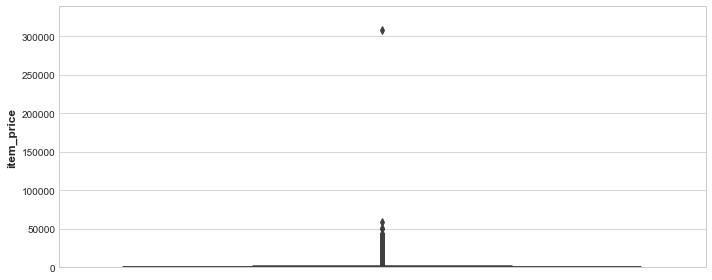

In [126]:
plt.figure(figsize=(10,4))

plt.ylim(df_train.item_price.min(), df_train.item_price.max()*1.1)
sns.boxplot(y=df_train.item_price)

<AxesSubplot:xlabel='item_cnt_day'>

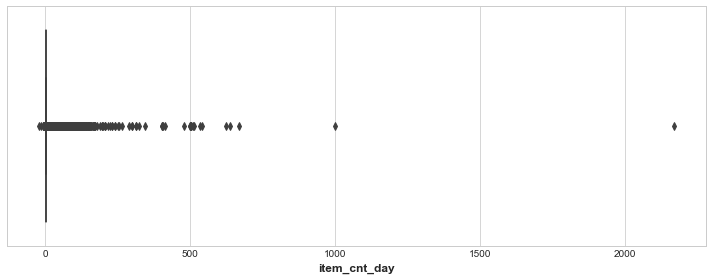

In [128]:
plt.figure(figsize=(10,4))
plt.ylim(df_train.item_cnt_day.min()-1,df_train.item_cnt_day.max()+1)
sns.boxplot(x=df_train.item_cnt_day)

In [266]:
df_train = df_train[df_train.item_price<100000]
df_train = df_train[df_train.item_cnt_day<1001]

In [267]:
median = df_train[(df_train.shop_id==32)&(df_train.item_id==2973)&(df_train.date_block_num==4)&(df_train.item_price>0)].item_price.median()
df_train.loc[df_train.item_price<0, 'item_price'] = median

In [268]:
# Якутск Орджоникидзе, 56
df_train.loc[df_train.shop_id == 0, 'shop_id'] = 57
df_test.loc[df_test.shop_id == 0, 'shop_id'] = 57
# Якутск ТЦ "Центральный"
df_train.loc[df_train.shop_id == 1, 'shop_id'] = 58
df_test.loc[df_test.shop_id == 1, 'shop_id'] = 58
# Жуковский ул. Чкалова 39м²
df_train.loc[df_train.shop_id == 10, 'shop_id'] = 11
df_test.loc[df_test.shop_id == 10, 'shop_id'] = 11

In [269]:
shops=df_shops.reset_index()
shops.loc[shops.shop_name == 'Сергиев Посад ТЦ "7Я"', 'shop_name'] = 'СергиевПосад ТЦ "7Я"'
shops['city'] = shops['shop_name'].str.split(' ').map(lambda x: x[0])
shops.loc[shops.city == '!Якутск', 'city'] = 'Якутск'
shops['city_code'] = LabelEncoder().fit_transform(shops['city'])
df_shops = shops[['shop_id','city_code']]

In [271]:
df_item_cat=df_item_cat.reset_index()
df_item_cat['split'] = df_item_cat['item_category_name'].str.split('-')
df_item_cat['type'] = df_item_cat['split'].map(lambda x: x[0].strip())
df_item_cat['type_code'] = LabelEncoder().fit_transform(df_item_cat['type'])
# if subtype is nan then type
df_item_cat['subtype'] = df_item_cat['split'].map(lambda x: x[1].strip() if len(x) > 1 else x[0].strip())
df_item_cat['subtype_code'] = LabelEncoder().fit_transform(df_item_cat['subtype'])
df_item_cat = df_item_cat[['item_category_id','type_code', 'subtype_code']]

,item_category_id,type_code,subtype_code
0,0,0,29
1,1,1,9
2,2,1,10
3,3,1,11
4,4,1,13
5,5,1,14
6,6,1,16
7,7,1,17
8,8,2,26
9,9,3,33


In [272]:
df_train['revenue'] = df_train['item_price'] *  df_train['item_cnt_day']

In [122]:
cols = ['date','date_block_num','shop_id','item_id','item_cnt_day']
print(df_train.duplicated(subset=cols).value_counts())
df_train[df_train.duplicated(subset=cols)].sort_values(by='date')

False    2935825
True          24
dtype: int64


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1671873,01.05.2014,16,50,3423,999.0,1
284372,02.03.2013,2,16,12133,1389.0,1
76962,05.01.2013,0,54,20130,149.0,1
408104,06.04.2013,3,54,14050,349.0,1
275476,07.03.2013,2,50,12133,889.0,1
2909373,07.10.2015,33,12,21619,499.0,1
1507629,09.03.2014,14,31,12133,599.0,1
2420539,12.02.2015,25,42,21619,499.0,1
1866340,12.07.2014,18,25,3423,999.0,1
1940058,14.08.2014,19,31,9842,98.0,1


# EDA

## Sets inspection

In [173]:
#By doing df_test.nunique() we discover that the 214 200 rows of df_test comes 
#from the combination of unique shop_id (42) and item_id (5100 combinations)
df_test.nunique()

shop_id      42
item_id    5100
dtype: int64

In [46]:
#Check if shops in test are contained in train : OK

list_shops_test=df_test.shop_id.unique()
list_shops_train=df_train.shop_id.unique()
set(list_shops_test).issubset(set(list_shops_train))

True

In [47]:
#Check if items in test are contained in train : KO

list_items_test=df_test.item_id.unique()
list_items_train=df_train.item_id.unique()
set(list_items_test).issubset(set(list_items_train))

False

In [48]:
#Check how many items from test are present in train:

test_items_in_train=list(set(list_items_test).intersection(list_items_train))
test_items_in_train=list(set(list_items_test).intersection(list_items_train))
test_items_not_in_train=list(set(list_items_test).difference(list_items_train))

print('Test contains {} items of which {} are in train and {} which are not'.format
      (len(list_items_test),len(test_items_in_train),len(test_items_not_in_train)))

df_test[item_id.isin(test_items_not_in_train)]

Test contains 5100 items of which 4737 are in train and 363 which are not


In [93]:
# By doing value_counts(), we see that df_train only has item+shop combinations with item_cnt>=1
#=> we need to account for that by creating a grid, manually inserting the 0 for the days without sales

df_train.item_cnt_day.value_counts().head(5)

1.0    2629372
2.0     194201
3.0      47350
4.0      19685
5.0      10474
Name: item_cnt_day, dtype: int64

In [194]:
len(df_train.item_id.unique())

21806

## Grid creation

### by reusing Programming Assignment Week 4 code

### to make things easier

##### We see that 99% of average item x shop monthly sales fall below 20
##### => we can clip values from 0 to 20

In [273]:
data=(sales.groupby(['shop_id','item_id'],as_index=False)
              .agg({'item_cnt_day':'mean'})['item_cnt_day']
              .value_counts().sort_index(ascending=True)
)
# data.values
np.percentile(data.index,99)

19.670021299254525

In [302]:
sales=df_train

df_test['date_block_num']=34
df_test.head()

# Create "grid" with columns
index_cols = ['shop_id', 'item_id', 'date_block_num']

# For every month we create a grid from all shops/items combinations from that month
grid = [] 
for block_num in sales['date_block_num'].unique():
    cur_shops = sales.loc[sales['date_block_num'] == block_num, 'shop_id'].unique()
    cur_items = sales.loc[sales['date_block_num'] == block_num, 'item_id'].unique()
    grid.append(np.array(list(product(*[cur_shops, cur_items, [block_num]])),dtype='int32'))

# Turn the grid into a dataframe
grid = pd.DataFrame(np.vstack(grid), columns = index_cols,dtype=np.int32)

# Groupby data to get shop-item-month aggregates

gb = sales.groupby(index_cols,as_index=False).agg({'item_cnt_day':'sum'})
gb = reduce_mem_usage(gb)

# Fix column names
 
gb = gb.rename(columns={'item_cnt_day':'target'})
# Join it to the grid
all_data = pd.merge(grid, gb, how='left', on=index_cols).fillna(0)
all_data['target']=all_data['target'].astype('int16')
all_data['target']=all_data['target'].clip(0,20)
#all_data = reduce_mem_usage(all_data)
                           
del gb;
gc.collect();

# Same as above but with shop-month aggregates


gb = sales.groupby(['shop_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':'sum'})
gb = gb.rename(columns={'item_cnt_day':'target_shop'})
gb = reduce_mem_usage(gb)

all_data = pd.merge(all_data, gb, how='left', on=['shop_id', 'date_block_num']).fillna(0)

# all_data = reduce_mem_usage(all_data)

del gb;
gc.collect();

# Same as above but with item-month aggregates
# gb = sales.groupby(['item_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':{'target_item':'sum'}})
# gb.columns = [col[0] if col[-1] == '' else col[-1] for col in gb.columns.values]

gb = sales.groupby(['item_id', 'date_block_num'],as_index=False).agg({'item_cnt_day':'sum'})
gb = gb.rename(columns={'item_cnt_day':'target_item'})
gb = reduce_mem_usage(gb)

all_data = pd.merge(all_data, gb, how='left', on=['item_id', 'date_block_num']).fillna(0)
all_data = reduce_mem_usage(all_data)

# Downcast dtypes from 64 to 32 bit to save memory
del grid, gb 

Memory usage after optimization is: 9.21 MB
Decreased by 76.9%
Memory usage after optimization is: 0.01 MB
Decreased by 77.4%
Memory usage after optimization is: 1.12 MB
Decreased by 72.2%
Memory usage after optimization is: 176.94 MB
Decreased by 34.6%


In [303]:
all_data.head()

,shop_id,item_id,date_block_num,target,target_shop,target_item
0,59,22154,0,1,2017,18
1,59,2552,0,0,2017,0
2,59,2554,0,0,2017,1
3,59,2555,0,0,2017,2
4,59,2564,0,0,2017,5


### Mean encoded features

In [304]:
def lag_feature(df, lags, col):
    tmp = df[['date_block_num','shop_id','item_id',col]]
    for i in lags:
        shifted = tmp.copy()
        shifted.columns = ['date_block_num','shop_id','item_id', col+'_lag_'+str(i)]
        shifted['date_block_num'] += i
        df = pd.merge(df, shifted, on=['date_block_num','shop_id','item_id'], how='left')
    return df

In [305]:
#Mean per month

group = all_data.groupby(['date_block_num']).agg({'target': ['mean']})
group.columns = [ 'date_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num'], how='left')
all_data['date_avg_item_cnt'] = all_data['date_avg_item_cnt'].astype(np.float16)
all_data = lag_feature(all_data, [1], 'date_avg_item_cnt')
all_data.drop(['date_avg_item_cnt'], axis=1, inplace=True)

#Mean per itemxmonth

group = all_data.groupby(['date_block_num', 'item_id']).agg({'target': ['mean']})
group.columns = [ 'date_item_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num','item_id'], how='left')
all_data['date_item_avg_item_cnt'] = all_data['date_item_avg_item_cnt'].astype(np.float16)
all_data = lag_feature(all_data, [1,2,3,6,12], 'date_item_avg_item_cnt')
all_data.drop(['date_item_avg_item_cnt'], axis=1, inplace=True)

#Mean per shopxmonth

group = all_data.groupby(['date_block_num', 'shop_id']).agg({'target': ['mean']})
group.columns = [ 'date_shop_avg_item_cnt' ]
group.reset_index(inplace=True)

all_data = pd.merge(all_data, group, on=['date_block_num','shop_id'], how='left')
all_data['date_shop_avg_item_cnt'] = all_data['date_shop_avg_item_cnt'].astype(np.float16)
all_data = lag_feature(all_data, [1,2,3,6,12], 'date_shop_avg_item_cnt')
all_data.drop(['date_shop_avg_item_cnt'], axis=1, inplace=True)

#Mean per item catxmonth

group = matrix.groupby(['date_block_num', 'item_category_id']).agg({'item_cnt_month': ['mean']})
group.columns = [ 'date_cat_avg_item_cnt' ]
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num','item_category_id'], how='left')
matrix['date_cat_avg_item_cnt'] = matrix['date_cat_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_cat_avg_item_cnt')
matrix.drop(['date_cat_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'shop_id', 'item_category_id']).agg({'item_cnt_month': ['mean']})
group.columns = ['date_shop_cat_avg_item_cnt']
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'shop_id', 'item_category_id'], how='left')
matrix['date_shop_cat_avg_item_cnt'] = matrix['date_shop_cat_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_shop_cat_avg_item_cnt')
matrix.drop(['date_shop_cat_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'shop_id', 'type_code']).agg({'item_cnt_month': ['mean']})
group.columns = ['date_shop_type_avg_item_cnt']
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'shop_id', 'type_code'], how='left')
matrix['date_shop_type_avg_item_cnt'] = matrix['date_shop_type_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_shop_type_avg_item_cnt')
matrix.drop(['date_shop_type_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'shop_id', 'subtype_code']).agg({'item_cnt_month': ['mean']})
group.columns = ['date_shop_subtype_avg_item_cnt']
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'shop_id', 'subtype_code'], how='left')
matrix['date_shop_subtype_avg_item_cnt'] = matrix['date_shop_subtype_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_shop_subtype_avg_item_cnt')
matrix.drop(['date_shop_subtype_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'city_code']).agg({'item_cnt_month': ['mean']})
group.columns = [ 'date_city_avg_item_cnt' ]
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'city_code'], how='left')
matrix['date_city_avg_item_cnt'] = matrix['date_city_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_city_avg_item_cnt')
matrix.drop(['date_city_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'item_id', 'city_code']).agg({'item_cnt_month': ['mean']})
group.columns = [ 'date_item_city_avg_item_cnt' ]
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'item_id', 'city_code'], how='left')
matrix['date_item_city_avg_item_cnt'] = matrix['date_item_city_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_item_city_avg_item_cnt')
matrix.drop(['date_item_city_avg_item_cnt'], axis=1, inplace=True)

group = matrix.groupby(['date_block_num', 'type_code']).agg({'item_cnt_month': ['mean']})
group.columns = [ 'date_type_avg_item_cnt' ]
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'type_code'], how='left')
matrix['date_type_avg_item_cnt'] = matrix['date_type_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_type_avg_item_cnt')
matrix.drop(['date_type_avg_item_cnt'], axis=1, inplace=True)

ts = time.time()
group = matrix.groupby(['date_block_num', 'subtype_code']).agg({'item_cnt_month': ['mean']})
group.columns = [ 'date_subtype_avg_item_cnt' ]
group.reset_index(inplace=True)

matrix = pd.merge(matrix, group, on=['date_block_num', 'subtype_code'], how='left')
matrix['date_subtype_avg_item_cnt'] = matrix['date_subtype_avg_item_cnt'].astype(np.float16)
matrix = lag_feature(matrix, [1], 'date_subtype_avg_item_cnt')
matrix.drop(['date_subtype_avg_item_cnt'], axis=1, inplace=True)

In [306]:
all_data.head()

,shop_id,item_id,date_block_num,target,target_shop,target_item,date_avg_item_cnt_lag_1,date_item_avg_item_cnt_lag_1,date_item_avg_item_cnt_lag_2,date_item_avg_item_cnt_lag_3,date_item_avg_item_cnt_lag_6,date_item_avg_item_cnt_lag_12,date_shop_avg_item_cnt_lag_1,date_shop_avg_item_cnt_lag_2,date_shop_avg_item_cnt_lag_3,date_shop_avg_item_cnt_lag_6,date_shop_avg_item_cnt_lag_12
0,59,22154,0,1,2017,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59,2552,0,0,2017,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59,2554,0,0,2017,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,59,2555,0,0,2017,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,59,2564,0,0,2017,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [307]:
list(all_data.columns.difference(index_cols)) 

['date_avg_item_cnt_lag_1',
 'date_item_avg_item_cnt_lag_1',
 'date_item_avg_item_cnt_lag_12',
 'date_item_avg_item_cnt_lag_2',
 'date_item_avg_item_cnt_lag_3',
 'date_item_avg_item_cnt_lag_6',
 'date_shop_avg_item_cnt_lag_1',
 'date_shop_avg_item_cnt_lag_12',
 'date_shop_avg_item_cnt_lag_2',
 'date_shop_avg_item_cnt_lag_3',
 'date_shop_avg_item_cnt_lag_6',
 'target',
 'target_item',
 'target_shop']

In [104]:
# List of columns that we will use to create lags
cols_to_rename = list(all_data.columns.difference(index_cols)) 

shift_range = [1, 2, 3, 4, 5, 12]

for month_shift in tqdm_notebook(shift_range):
    train_shift = all_data[index_cols + cols_to_rename].copy()
    
    train_shift['date_block_num'] = train_shift['date_block_num'] + month_shift
    
    foo = lambda x: '{}_lag_{}'.format(x, month_shift) if x in cols_to_rename else x
    train_shift = train_shift.rename(columns=foo)

    all_data = pd.merge(all_data, train_shift, on=index_cols, how='left').fillna(0)

    #add test
    df_test = pd.merge(df_test,train_shift,on=index_cols, how='left').fillna(0)
    
del train_shift
gc.collect()

# Don't use old data from year 2013
all_data = all_data[all_data['date_block_num'] >= 12] 

# List of all lagged features
fit_cols = [col for col in all_data.columns if col[-1] in [str(item) for item in shift_range]] 
# We will drop these at fitting stage
to_drop_cols = list(set(list(all_data.columns)) - (set(fit_cols)|set(index_cols))) + ['date_block_num'] 

# Category for each item
item_category_mapping = items[['item_id','item_category_id']].drop_duplicates()

all_data = pd.merge(all_data, item_category_mapping, how='left', on='item_id')
all_data = reduce_mem_usage(all_data)

df_test = pd.merge(df_test, item_category_mapping, how='left', on='item_id')
df_test = reduce_mem_usage(df_test)

gc.collect();


Memory usage after optimization is: 337.01 MB
Decreased by 67.6%
Memory usage after optimization is: 10.01 MB
Decreased by 71.3%


In [23]:
all_data.head(3)

,shop_id,item_id,date_block_num,target,target_shop,target_item,target_lag_1,target_item_lag_1,target_shop_lag_1,target_lag_2,target_item_lag_2,target_shop_lag_2,target_lag_3,target_item_lag_3,target_shop_lag_3,target_lag_4,target_item_lag_4,target_shop_lag_4,target_lag_5,target_item_lag_5,target_shop_lag_5,target_lag_12,target_item_lag_12,target_shop_lag_12,item_category_id
0,54,10297,12,4,8198,23,3.0,42.0,10056.0,0.0,2.0,7976.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37
1,54,10296,12,3,8198,17,0.0,24.0,10056.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38
2,54,10298,12,14,8198,182,21.0,369.0,10056.0,119.0,1309.0,7976.0,7.0,144.0,6676.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40


In [10]:
all_data.shape

(6425094, 25)

## Training

### Dates present in training dataset

In [89]:
dates = all_data['date_block_num']
dates.unique()

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33], dtype=int8)

## First level models

## Hyperparametrization
### Models: Linear Regression, XGBoost, RandomForest


#### Note: I tried k-NN and Linear SVM that theyb were not successful


In [61]:
# we use last month of train, i.e. 33, as validation ('test')

last_block=33
dates = all_data['date_block_num']
dates_train = dates[dates <  last_block]
dates_test  = dates[dates == last_block]

X_train = all_data.loc[dates <  last_block].drop(to_drop_cols, axis=1)
X_test =  all_data.loc[dates == last_block].drop(to_drop_cols, axis=1)

y_train = all_data.loc[dates <  last_block, 'target'].values
y_test =  all_data.loc[dates == last_block, 'target'].values

## Baseline Models

### Linear Regression

### Note: features are around same level of magnitude, no need to standarize/normalize data

In [13]:
# lr = LinearRegression()
# lr.fit(X_train, y_train)
# pred_lr = lr.predict(X_test)

# print('Test R-squared for linreg is %f' % r2_score(y_test, pred_lr))

Test R-squared for linreg is 0.254874


### XGBoost Regression

In [186]:
# base_model = XGBRegressor()

# base_model.fit(X_train,y_train)

# # y_valid_pred_lr = model.predict(X_valid)
# pred_xgb = base_model.predict(X_test)
# print('Test R-squared for XGBoost is %f' % r2_score(y_test, pred_xgb))
# # r2_score(y_valid,y_valid_pred_lr)

Test R-squared for XGBoost is 0.266295


#### XGBoost: Hyperparameters tuning with Optuna

In [187]:
# def score_dataset(X_train,y_train,X_test,model=XGBRegressor()):
    
#     model.fit(X_train,y_train)
    
#     pred=model.predict(X_test)
    
#     score = r2_score(y_test,pred)
    
#     return score

In [90]:
# import optuna

# def objective(trial):
#     xgb_params = dict(
#         max_depth=trial.suggest_int("max_depth", 2, 10),
#         learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
#         n_estimators=trial.suggest_int("n_estimators", 700, 1700),
#         min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
#         colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 1.0),
#         subsample=trial.suggest_float("subsample", 0.2, 1.0),
#         reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
#         reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
#     )
#     xgb = XGBRegressor(**xgb_params)
#     return score_dataset(X_train, y_train, X_test, xgb)

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=12)
# xgb_params = study.best_params

### Best params after Optuna optimization are:

In [28]:
# xgs_params=dict(max_depth=9,
#  learning_rate=0.09644466944845043,
#  n_estimators=701,
#  min_child_weight=3,
#  colsample_bytree=0.4342385606624722,
#  subsample=0.9794759674096296,
#  reg_alpha=0.28416962200877754,
#  reg_lambda=0.051808155522821586)

### LightGBM

#### Because we already have XGBoost and its baseline model performs better than baseline LightGBM => I will not use LightGBM

## k-NN Regressor

### Note: I finally didn't use k-NN since it takes a lot of time to converge and doesn't give meaningful results

Best n is 0.0940077539558346 and best r2 score is 10 


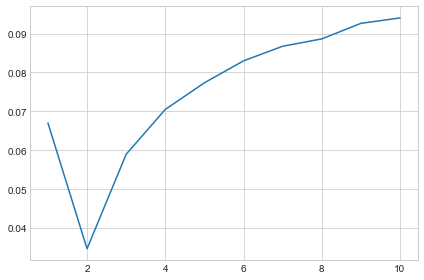

In [14]:
# from sklearn.neighbors import KNeighborsRegressor

# list_r2_score_knn=[]

# for n in range(1,11):
#     neigh = KNeighborsRegressor(n_neighbors=n)
#     neigh.fit(X_train,y_train)
#     y_test_knn=neigh.predict(X_test)
    
#     r2_score_knn=r2_score(y_test, y_test_knn)
#     list_r2_score_knn.append(r2_score_knn)
    

# best_r2_score=max(list_r2_score_knn)
# best_n=list(range(1,11))[np.argmax(list_r2_score_knn)]

# plt.figure()
# plt.plot(range(1,11),list_r2_score_knn)

# print('Best n is {} and best r2 score is {} '.format(best_r2_score,best_n))

In [ ]:
# #Best n = 10
# neigh=KNeighborsRegressor(n_neighbors=10)
# neigh.fit(X_train,y_train)
# y_test_knn=neigh.predict(X_test)

## Random Forest Regressor

### Base model:

In [31]:
# from sklearn.ensemble import RandomForestRegressor
# regr = RandomForestRegressor(random_state=0)
# regr.fit(X_train, y_train)
# y_test_RF=regr.predict(X_test)
# print('Test R-squared for RF is %f' % r2_score(y_test, y_test_RF))

Test R-squared for RF is 0.425614


### Hyperparam tuning with scikit opt

In [34]:
# from skopt import gp_minimize
# from skopt.space import Real, Integer
# from skopt.utils import use_named_args
# from sklearn.ensemble import RandomForestRegressor

# n_features = X_train.shape[1]

# space  = [Integer(1, 5, name='max_depth'),
#           Integer(1, n_features, name='max_features'),
#           Integer(2, 100, name='min_samples_split'),
#           Integer(1, 100, name='min_samples_leaf')]

# @use_named_args(space)

# def objective(**params):
    
#     regr = RandomForestRegressor(random_state=0)
    
#     regr.set_params(**params)
    
#     regr.fit(X_train, y_train)
    
#     y_test_RF=regr.predict(X_test)
    
#     score = (-1) * r2_score(y_test,y_test_RF)
    
#     return score


In [36]:
# res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)
# "Best score=%.4f" % res_gp.fun

'Best score=-0.2586'

In [51]:
# print("""Best parameters:
# - max_depth=%d
# - max_features=%d
# - min_samples_split=%d
# - min_samples_leaf=%d""" % (res_gp.x[0], res_gp.x[1],
#                             res_gp.x[2], res_gp.x[3]))

Best parameters:
- max_depth=5
- max_features=21
- min_samples_split=2
- min_samples_leaf=47


### Random Forest: Feature Importances

In [91]:
# feat=pd.DataFrame(data=regr.feature_importances_,index=X_train.columns)
# feat.sort_values(by=0,ascending=False)[:10]

,0
target_lag_1,0.431403
target_item_lag_5,0.138959
target_item_lag_1,0.103115
target_item_lag_4,0.083907
target_item_lag_2,0.074499
target_item_lag_3,0.074054
target_lag_2,0.037784
target_lag_5,0.018893
target_lag_4,0.018828
target_lag_3,0.018559


## Test Meta features

In [95]:
# X_train from 12 to 33
X_train = all_data.drop(to_drop_cols,axis=1)
y_train = all_data.target

# X_train month 34
X_test = df_test.drop('date_block_num',axis=1)

In [96]:
X_test.describe()

,shop_id,item_id,item_category_id_lag_1,target_lag_1,target_item_lag_1,target_item_lag_1_lag_1,target_item_lag_12_lag_1,target_item_lag_2_lag_1,target_item_lag_3_lag_1,target_item_lag_4_lag_1,target_item_lag_5_lag_1,target_lag_1_lag_1,target_lag_12_lag_1,target_lag_2_lag_1,target_lag_3_lag_1,target_lag_4_lag_1,target_lag_5_lag_1,target_shop_lag_1,target_shop_lag_1_lag_1,target_shop_lag_12_lag_1,target_shop_lag_2_lag_1,target_shop_lag_3_lag_1,target_shop_lag_4_lag_1,target_shop_lag_5_lag_1
count,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.0,214200.0,214200.0,214200.0,214200.0,214200.0,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000,214200.0,214200.0,214200.0,214200.0,214200.0,214200.0
mean,31.642857,11019.398627,36.220588,0.293413,13.289608,NaN,NaN,NaN,NaN,NaN,NaN,0.271973,0.239746,0.274902,0.239746,0.237061,0.258057,1215.913487,NaN,NaN,NaN,NaN,NaN,NaN
std,17.561933,6252.644590,24.176697,5.550976,75.376194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1344.777606,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,30.000000,0.000000,-1.000000,0.000000,0.0,0.0,-1.0,-1.0,0.0,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,16.000000,5381.500000,19.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,383.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,34.500000,11203.000000,40.000000,0.000000,4.000000,3.0,0.0,2.0,2.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,997.000000,906.0,0.0,932.0,678.0,622.0,466.0
75%,47.000000,16071.500000,55.000000,0.000000,11.000000,9.0,6.0,10.0,9.0,8.0,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1409.000000,1357.0,1187.0,1409.0,1299.0,1141.0,1257.0
max,59.000000,22167.000000,83.000000,2253.000000,4078.000000,3390.0,6548.0,3552.0,3348.0,3472.0,3768.0,473.000000,634.000000,436.000000,482.000000,444.000000,742.000000,6247.000000,6868.0,8456.0,5712.0,5988.0,6160.0,6328.0


### Note: k-NN and LSVM were finally discarded

In [160]:
# #Linear Reg:

# lr = LinearRegression()
# lr.fit(X_train, y_train)
# y_test_lr = lr.predict(X_test)

# #XGBoost:

# xgb_test=XGBRegressor(**xgb_params)
# xgb_test.fit(X_train,y_train)
# y_test_xgb=xgb_test.predict(X_test)

# #kNN

# # neigh=KNeighborsRegressor(n_neighbors=5)
# # neigh.fit(X_train,y_train)
# # y_test_kNN=neigh.predict(X_test)

# #Random-Forest:

# regr = RandomForestRegressor(random_state=0,
#                              max_depth=5,
#                              max_features=21
#                              min_samples_split=2,
#                              min_samples_leaf=47)

# regr.fit(X_train, y_train)

# y_test_RF=regr.predict(X_test)

# # #Linear SVM:

# # LSVR = LinearSVR(random_state=0,
# #                  C=0.01,
# #                  tol=1e-4,
# #                  epsilon=0,
# #                  max_iter=645)


# # LSVR.fit(X_train,y_train)

# # y_test_lsvr=LSVR.predict(X_test)



# # X_test_level2 = np.c_[y_test_lr,y_test_xgb,y_test_kNN,y_test_RF,y_test_lsvr]
# X_test_level2 = np.c_[y_test_lr,y_test_xgb,y_test_RF]

### Test level 2 definition

In [ ]:
#Note: previous cell takes a long time, I saved predictions in a pickle
X_test_level2 = pd.read_pickle(data_dir / "test_predictions.pkl",compression='gzip')

## Validation scheme

##### Time Series - K-fold Scheme with M = 15

##### X_train from 12 to 26

##### X_valid from 27 to 33

##### X_test = df_test.drop('date_block_num',axis=1)

### Train meta features

In [25]:
#date min = 12
#date max = 33
#M=15

#first M=15 chucks => from 12 to 26 is train / 27 to 33 is valid / 34 is test
dates = all_data['date_block_num']

dates_train_level2 = dates[dates.isin([27, 28, 29, 30, 31, 32, 33])]

# target for the 2nd level dataset is equal to validation (from month 27 to 33)
y_train_level2 = y_train[dates.isin([27, 28, 29, 30, 31, 32, 33])]

In [103]:
# # And here we create 2nd level feature matrix, initialize it with zeros first
# X_train_level2 = np.zeros([y_train_level2.shape[0], 3])

# # Now fill `X_train_level2` with metafeatures
# for cur_block_num in [27, 28, 29, 30, 31, 32, 33]:
    
#     print(cur_block_num)
    
#     '''
#         1. Split `X_train` into parts
#            Remember, that corresponding dates are stored in `dates_train` 
#         2. Fit linear regression, XGB, kNN, RF, LVSM       
#         3. Store predictions from 2. in the right place of `X_train_level2`, using `dates_train_level2` for it
#            Make sure the order of the meta-features is the same as in `X_test_level2`
#     '''      
    
#     #1. Split 'X_train'
#     X_train_tr=X_train[dates.isin(range(12,cur_block_num))]
#     X_train_ts=X_train[dates==cur_block_num]
    
#     y_train_tr=y_train[dates.isin(range(12,cur_block_num))]
    
#     #Linear Reg:

#     lr = LinearRegression()
#     lr.fit(X_train_tr, y_train_tr)
#     pred_lr = lr.predict(X_train_ts)

#     #XGBoost:

#     xgb=XGBRegressor(max_depth=9,
#      learning_rate=0.09644466944845043,
#      n_estimators=701,
#      min_child_weight=3,
#      colsample_bytree=0.4342385606624722,
#      subsample=0.9794759674096296,
#      reg_alpha=0.28416962200877754,
#      reg_lambda=0.051808155522821586
#      tree_method='gpu_hist')
#      xgb.fit(X_train_tr,y_train_tr)
        
#     pred_xgb=xgb.predict(X_train_ts)

# #     #kNN

# #     neigh=KNeighborsRegressor(n_neighbors=5)
# #     neigh.fit(X_train_tr,y_train_tr)
# #     pred_knn=neigh.predict(X_train_ts)

#     #Random-Forest:

#     regr = RandomForestRegressor(random_state=0,
#                              max_depth=5,
#                              max_features=21
#                              min_samples_split=2,
#                              min_samples_leaf=47,
#                              njobs=-1)
    
#     regr.fit(X_train_tr, y_train_tr)

#     pred_RF=regr.predict(X_train_ts)
     
#     # index in dates_train_level2 start from 12000... but X_train_level2 in 0
#     # => before assigning a value, we need to convert dates_train_level2 indexes
   
#     min_idx_abs=dates_train_level2.index.min()
#     min_idx_date=dates_train_level2[dates_train_level2==cur_block_num].index.min()
#     max_idx_date=dates_train_level2[dates_train_level2==cur_block_num].index.max()
    
#     idx_min=min_idx_date-min_idx_abs
#     idx_max=max_idx_date-min_idx_abs
    
#     X_train_level2[idx_min:idx_max+1]=np.c_[pred_lr, pred_xgb,pred_RF]

27
28
29
30
31
32
33


### Note: previous algorithm takes a long time to execute (approx 10 hours, so I save a copy below)

In [11]:
X_train_level2=pd.read_pickle('X_train_level2.pkl',compression='gzip')

In [12]:
X_train_level2.shape

(1614364, 3)

## Stacking

## Simple ensembling

In [159]:
# train_pred=pd.DataFrame(X_train_level2,columns=['LinReg','lightGBM'])
# alphas_to_try = np.linspace(0, 1, 1001)

# r2_list=[]
# alpha_list=[]

# r2_dict={}

# for alpha in alphas_to_try:
    
#     mix_pred = alpha * train_pred['LinReg'] + (1-alpha) * train_pred['lightGBM']
    
#     r2_score_alpha=r2_score(y_train_level2, mix_pred)
    
#     alpha_list.append(alpha)
#     r2_list.append(r2_score_alpha)
    
    
# # YOUR CODE GOES HERE
# best_alpha = alpha_list[np.argmax(np.array(r2_list))]
# r2_train_simple_mix = max(r2_list)

# print('Best alpha: %f; Corresponding r2 score on train: %f' % (best_alpha, r2_train_simple_mix))

Best alpha: 0.159000; Corresponding r2 score on train: 0.271734


### Check if level 2 train and test are consistent with target

In [136]:
train_level2=pd.DataFrame(X_train_level2,columns=['LinReg','XGBoost','RF'])
train_level2['target']=y_train_level2.values
train_level2.describe()

,LinReg,XGBoost,kNN,RF,LightSVM,target
count,37758.000000,37758.000000,37758.000000,37758.000000,37758.000000,37758.000000
mean,1.499945,1.358775,1.166741,1.340257,2.617037,1.241671
std,5.223085,3.770078,5.116008,3.363588,5.271522,5.630498
min,-6.714619,-2.141529,-0.200000,1.088758,-12.077331,-2.000000
25%,0.536001,0.431561,0.400000,1.090202,0.578869,0.000000
50%,1.008364,0.827568,0.600000,1.093698,2.173748,1.000000
75%,1.642254,1.420822,1.200000,1.097644,3.805810,1.000000
max,371.546417,237.088821,337.800000,221.404072,277.368855,328.000000


In [162]:
test_level2=pd.DataFrame(X_test_level2,columns=['LinReg','XGBoost','kNN','RF','LightSVM'])
test_level2.describe()

,LinReg,XGBoost,kNN,RF,LightSVM
count,214200.000000,214200.000000,214200.000000,214200.000000,214200.000000
mean,3.627380,3.091035,2.185178,1.095367,5.710813
std,9.508464,6.152553,5.589885,0.470013,3.361364
min,-12.536851,-0.450475,-0.200000,1.091886,-18.877870
25%,-4.835865,0.817034,0.400000,1.091886,3.585503
50%,5.326587,1.404710,0.800000,1.091886,5.823806
75%,11.915655,1.969160,1.800000,1.091886,8.075881
max,262.036224,247.860992,211.600000,195.449708,218.494054


### Simple averaging of Linear Reg, XGBoost and Random Forest

In [54]:
pred_simple_average=pd.DataFrame(X_test_level2.loc[:,['LinReg','XGBoost','RF']],columns=['LinReg','XGBoost','RF'])

submission_simple_avg = ((0.33 * pred_simple_average['LinReg']) +
              (0.33 * pred_simple_average['XGBoost']) +
              (0.33 * pred_simple_average['RF'])
             )

In [85]:
submission_simple_avg.clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('simple_avg.csv',index=False)

In [98]:
# !cat simple_avg.csv

## Stacking

## Tried Linear Reg and XGBoost => Linear Reg was better (less overfitting)

In [41]:
#1. Fit Lin Regression
lr = LinearRegression()
lr.fit(X_train_level2.iloc[:,:3], y_train_level2)

pred_lr_test = lr.predict(X_test_level2.loc[:,['LinReg','XGBoost','RF']])

pd.Series(pred_lr_test).clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('Stack_LR.csv',index=False)

In [99]:
#2 Fit XGBoost
# from xgboost import XGBRegressor
# xgb = XGBRegressor()
# xgb.fit(X_train_level2, y_train_level2)

# pred_xgb = xgb.predict(X_test_level2.loc[:,['LinReg','XGBoost','RF']])

# pd.Series(pred_xgb).clip(0,20).to_frame().reset_index().rename(columns={'index':'ID',0:'item_cnt_month'}).to_csv('Stack_XGB.csv',index=False)


## Best score: 0.958

Your solution is good already, but there is laways a room for improvements! Keep on! Your public and private LB scores are: 0.958911 and 0.960822.